# Step1:Load Dataset & preprocessing






In [2]:
import pandas as pd
from datasets import load_dataset

# Yelp
dataset = load_dataset('yelp_review_full')
df = dataset['train'].to_pandas()
df = df[['text', 'label']].sample(n=10000, random_state=42)
df['stars'] = df['label'] + 1

# Sentiment mapping
def rating_to_sentiment(r):
    if r >= 4:   return 'Positive'
    elif r == 3: return 'Neutral'
    else:        return 'Negative'

df['sentiment'] = df['stars'].apply(rating_to_sentiment)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…):   0%|          | 0.00/299M [00:00<?, ?B/s]

yelp_review_full/test-00000-of-00001.par(…):   0%|          | 0.00/23.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [3]:
pd.set_option('display.max_columns',None)
df.head(5)

,text,label,stars,sentiment
177288,"First of all i'm not a big fan of buffet, i tr...",0,1,Negative
238756,Thanks Yelp. I was looking for the words to de...,1,2,Negative
604225,Service was so-so. They were receiving a deliv...,2,3,Neutral
2838,Stamoolis Brothers is one of the Strip Distric...,2,3,Neutral
586957,I want to give a 2 stars because the service s...,0,1,Negative


In [4]:
df.info

<bound method DataFrame.info of                                                      text  label  stars  \
177288  First of all i'm not a big fan of buffet, i tr...      0      1   
238756  Thanks Yelp. I was looking for the words to de...      1      2   
604225  Service was so-so. They were receiving a deliv...      2      3   
2838    Stamoolis Brothers is one of the Strip Distric...      2      3   
586957  I want to give a 2 stars because the service s...      0      1   
...                                                   ...    ...    ...   
456268  Four Hours of my life I'd like to have back!\n...      0      1   
259135  Small stadium and would have great views all a...      1      2   
496284  I think Porktropolis has the BBQ thing nailed....      2      3   
512684  Best CU ever!!! Great customer service!!! Know...      4      5   
597788  Came in for late lunch on a Tuesday. I sat at ...      2      3   

       sentiment  
177288  Negative  
238756  Negative  
604225   Neutral  
2838     Neutral  
586957  Negative  
...          ...  
456268  Negative  
259135  Negative  
496284   Neutral  
512684  Positive  
597788   Neutral  

[10000 rows x 4 columns]>

In [5]:
df.describe()

,label,stars
count,10000.000000,10000.000000
mean,1.998100,2.998100
std,1.410849,1.410849
min,0.000000,1.000000
25%,1.000000,2.000000
50%,2.000000,3.000000
75%,3.000000,4.000000
max,4.000000,5.000000


In [6]:
df.columns

Index(['text', 'label', 'stars', 'sentiment'], dtype='object')

In [7]:
df.isnull().sum()

,0
text,0
label,0
stars,0
sentiment,0


In [8]:
df.duplicated().sum()

np.int64(0)

# Step 2:Text Cleaning

In [9]:
import re

def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s!?.,\'"-]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)
df.to_csv('preprocessed_data.csv', index=False)

# Step 3: SVM + TF-IDF

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['sentiment'],
    test_size=0.2, random_state=42, stratify=df['sentiment']
)

tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

svm = SVC(kernel='linear', C=1.0)
svm.fit(X_train_tfidf, y_train)

preds = svm.predict(X_test_tfidf)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

    Negative       0.78      0.86      0.82       805
     Neutral       0.53      0.37      0.44       396
    Positive       0.80      0.84      0.82       799

    accuracy                           0.75      2000
   macro avg       0.70      0.69      0.69      2000
weighted avg       0.74      0.75      0.74      2000



# Step 4:results for comparison

In [11]:
import pickle
pickle.dump(tfidf, open('tfidf_vectorizer.pkl', 'wb'))
pickle.dump(svm,   open('svm_model.pkl', 'wb'))

# Save metrics as dict for Person 3 to use in comparison
svm_report = classification_report(y_test, preds, output_dict=True)

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [13]:
# Pull from GitHub or Google Drive
df = pd.read_csv('preprocessed_data.csv')
df = df.dropna(subset=['clean_text']).reset_index(drop=True)

label_map   = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
label_names = ['Negative', 'Neutral', 'Positive']
df['label_id'] = df['sentiment'].map(label_map)

print(f"Total samples: {len(df)}")
print(df['sentiment'].value_counts())

Total samples: 10000
sentiment
Negative    4025
Positive    3995
Neutral     1980
Name: count, dtype: int64


In [14]:
X = df['clean_text'].tolist()
y = df['label_id'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 7000 | Val: 1500 | Test: 1500


In [15]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 128

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(0),
            'attention_mask' : encoding['attention_mask'].squeeze(0),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

BATCH_SIZE   = 32
train_loader = DataLoader(ReviewDataset(X_train, y_train, tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(ReviewDataset(X_val,   y_val,   tokenizer, MAX_LEN), batch_size=BATCH_SIZE)
test_loader  = DataLoader(ReviewDataset(X_test,  y_test,  tokenizer, MAX_LEN), batch_size=BATCH_SIZE)
print(f"Loaders ready | Train batches: {len(train_loader)}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaders ready | Train batches: 219


In [16]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label={0: 'Negative', 1: 'Neutral', 2: 'Positive'},
    label2id={'Negative': 0, 'Neutral': 1, 'Positive': 2}
).to(device)

print("Model loaded")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded


In [17]:
def train_epoch(model, loader, optimizer, criterion, scheduler=None):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        lbls = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(ids, mask)
        loss    = criterion(outputs.logits, lbls)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler: scheduler.step()

        total_loss += loss.item()
        preds       = outputs.logits.argmax(dim=1)
        correct    += (preds == lbls).sum().item()
        total      += lbls.size(0)

    return total_loss / len(loader), correct / total

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            lbls = batch['label'].to(device)

            outputs = model(ids, mask)
            loss    = criterion(outputs.logits, lbls)

            total_loss += loss.item()
            preds       = outputs.logits.argmax(dim=1)
            correct    += (preds == lbls).sum().item()
            total      += lbls.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels

In [18]:
EPOCHS   = 4
LR       = 2e-5
WARMUP   = 0.1
PATIENCE = 2

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)
criterion = nn.CrossEntropyLoss()

history        = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc   = 0
patience_count = 0

print("Training DistilBERT")
print("=" * 55)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc       = train_epoch(model, train_loader, optimizer, criterion, scheduler)
    vl_loss, vl_acc, _, _ = eval_epoch(model, val_loader, criterion)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc   = vl_acc
        patience_count = 0
        torch.save(model.state_dict(), 'best_distilbert.pt')
        print(f"  ✅ Best model saved (val_acc={vl_acc:.4f})")
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"  Early stopping at epoch {epoch}")
            break

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}")

Training DistilBERT
  ✅ Best model saved (val_acc=0.7633)
Epoch 1/4 | Train Loss: 0.7691 Acc: 0.6567 | Val Loss: 0.5857 Acc: 0.7633
Epoch 2/4 | Train Loss: 0.5231 Acc: 0.7841 | Val Loss: 0.5984 Acc: 0.7633
  Early stopping at epoch 3


In [19]:
# Cell 1 — Install dependencies
!pip install transformers datasets torch scikit-learn --quiet

In [20]:
# Cell 2 — Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [21]:
# Cell 3 — Load and rebuild data
# Option A: Load from GitHub (replace URL with your repo)
# df = pd.read_csv('https://raw.githubusercontent.com/yourteam/repo/main/data/preprocessed_data.csv')

# Option B: Load from Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/preprocessed_data.csv')

# Option C: Rebuild directly (use if Person 1 file not available)
from datasets import load_dataset
import re

print('Loading Yelp dataset...')
dataset = load_dataset('yelp_review_full')
df = dataset['train'].to_pandas()
df = df[['text', 'label']].sample(n=20000, random_state=42)  # increased from 10000
df['stars'] = df['label'] + 1

def rating_to_sentiment(r):
    if r >= 4:   return 'Positive'
    elif r == 3: return 'Neutral'
    else:        return 'Negative'

df['sentiment'] = df['stars'].apply(rating_to_sentiment)

def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s!?.,\'"-]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)
df = df.dropna(subset=['clean_text']).reset_index(drop=True)

print(f'Dataset loaded: {len(df)} rows')
print(df['sentiment'].value_counts())

Loading Yelp dataset...
Dataset loaded: 20000 rows
sentiment
Negative    7993
Positive    7968
Neutral     4039
Name: count, dtype: int64


In [22]:
# Cell 4 — Label encoding
label_map   = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
label_names = ['Negative', 'Neutral', 'Positive']
df['label_id'] = df['sentiment'].map(label_map)

print('Label distribution:')
print(df['sentiment'].value_counts())

Label distribution:
sentiment
Negative    7993
Positive    7968
Neutral     4039
Name: count, dtype: int64


In [23]:
# Cell 5 — Train / Val / Test split
X = df['clean_text'].tolist()
y = df['label_id'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Train : {len(X_train)}')
print(f'Val   : {len(X_val)}')
print(f'Test  : {len(X_test)}')

Train : 14000
Val   : 3000
Test  : 3000


In [24]:
# Cell 6 — Class weights to fix Neutral imbalance
weights = compute_class_weight(
    'balanced',
    classes=np.array([0, 1, 2]),
    y=y_train
)
class_weights_tensor = torch.tensor(weights, dtype=torch.float).to(device)
print('Class weights:', dict(zip(label_names, weights.round(3))))

Class weights: {'Negative': np.float64(0.834), 'Neutral': np.float64(1.651), 'Positive': np.float64(0.837)}


In [25]:
# Cell 7 — Tokenizer
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 128

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
print('Tokenizer loaded')

Tokenizer loaded


In [26]:
# Cell 8 — Dataset class and DataLoaders
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(0),
            'attention_mask' : encoding['attention_mask'].squeeze(0),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

BATCH_SIZE = 32

train_loader = DataLoader(ReviewDataset(X_train, y_train, tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(ReviewDataset(X_val,   y_val,   tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(ReviewDataset(X_test,  y_test,  tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 438
Val batches   : 94
Test batches  : 94


In [27]:
# Cell 9 — Load DistilBERT
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label={0: 'Negative', 1: 'Neutral', 2: 'Positive'},
    label2id={'Negative': 0, 'Neutral': 1, 'Positive': 2}
).to(device)

print('Model loaded')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded


In [28]:
# Cell 10 — Training and evaluation functions
def train_epoch(model, loader, optimizer, criterion, scheduler=None):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in loader:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        lbls = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(ids, mask)
        loss    = criterion(outputs.logits, lbls)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler: scheduler.step()

        total_loss += loss.item()
        preds       = outputs.logits.argmax(dim=1)
        correct    += (preds == lbls).sum().item()
        total      += lbls.size(0)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            lbls = batch['label'].to(device)

            outputs = model(ids, mask)
            loss    = criterion(outputs.logits, lbls)

            total_loss += loss.item()
            preds       = outputs.logits.argmax(dim=1)
            correct    += (preds == lbls).sum().item()
            total      += lbls.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels


print('Training functions defined')

Training functions defined


In [29]:
# Cell 11 — Hyperparameters and optimizer
EPOCHS   = 4
LR       = 3e-5   # increased from 2e-5 to escape plateau
WARMUP   = 0.1
PATIENCE = 3      # increased from 2

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# Weighted loss to handle Neutral class imbalance
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print(f'Total steps  : {total_steps}')
print(f'Warmup steps : {warmup_steps}')
print(f'LR           : {LR}')
print(f'Patience     : {PATIENCE}')

Total steps  : 1752
Warmup steps : 175
LR           : 3e-05
Patience     : 3


In [30]:
# Cell 12 — Training loop
history        = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc   = 0
patience_count = 0

print('Training DistilBERT')
print('=' * 55)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc        = train_epoch(model, train_loader, optimizer, criterion, scheduler)
    vl_loss, vl_acc, _, _  = eval_epoch(model, val_loader, criterion)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc   = vl_acc
        patience_count = 0
        torch.save(model.state_dict(), 'best_distilbert.pt')
        print(f'  ✅ Best model saved (val_acc={vl_acc:.4f})')
    else:
        patience_count += 1
        print(f'  No improvement. Patience: {patience_count}/{PATIENCE}')
        if patience_count >= PATIENCE:
            print(f'  Early stopping triggered at epoch {epoch}')
            break

    print(f'Epoch {epoch}/{EPOCHS} | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}')
    print('-' * 55)

print(f'\nBest val accuracy: {best_val_acc:.4f}')

Training DistilBERT
  ✅ Best model saved (val_acc=0.7337)
Epoch 1/4 | Train Loss: 0.7611 Acc: 0.6634 | Val Loss: 0.6566 Acc: 0.7337
-------------------------------------------------------
  ✅ Best model saved (val_acc=0.7543)
Epoch 2/4 | Train Loss: 0.5466 Acc: 0.7850 | Val Loss: 0.6988 Acc: 0.7543
-------------------------------------------------------
  No improvement. Patience: 1/3
Epoch 3/4 | Train Loss: 0.3858 Acc: 0.8634 | Val Loss: 0.7481 Acc: 0.7440
-------------------------------------------------------
  No improvement. Patience: 2/3
Epoch 4/4 | Train Loss: 0.2629 Acc: 0.9147 | Val Loss: 0.8533 Acc: 0.7473
-------------------------------------------------------

Best val accuracy: 0.7543


In [31]:
# Cell 13 — Test set evaluation
model.load_state_dict(torch.load('best_distilbert.pt', map_location=device))
_, test_acc, test_preds, test_true = eval_epoch(model, test_loader, criterion)

print(f'Test Accuracy: {test_acc:.4f}')
print('\nClassification Report:')
print(classification_report(test_true, test_preds, target_names=label_names))

bert_report = classification_report(
    test_true, test_preds,
    target_names=label_names,
    output_dict=True
)

Test Accuracy: 0.7700

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.79      0.82      1199
     Neutral       0.52      0.51      0.51       606
    Positive       0.81      0.88      0.84      1195

    accuracy                           0.77      3000
   macro avg       0.73      0.73      0.73      3000
weighted avg       0.77      0.77      0.77      3000



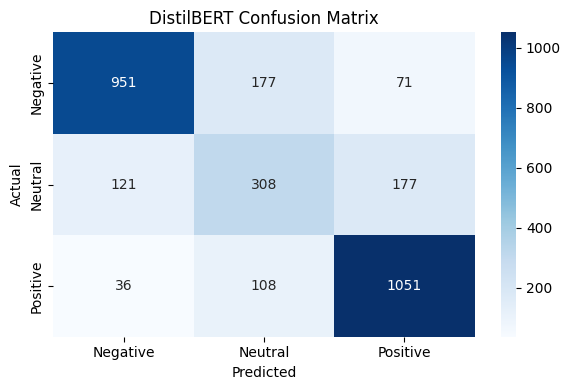

Saved: confusion_matrix.png


In [32]:
# Cell 14 — Confusion matrix
cm = confusion_matrix(test_true, test_preds)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('DistilBERT Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Saved: confusion_matrix.png')

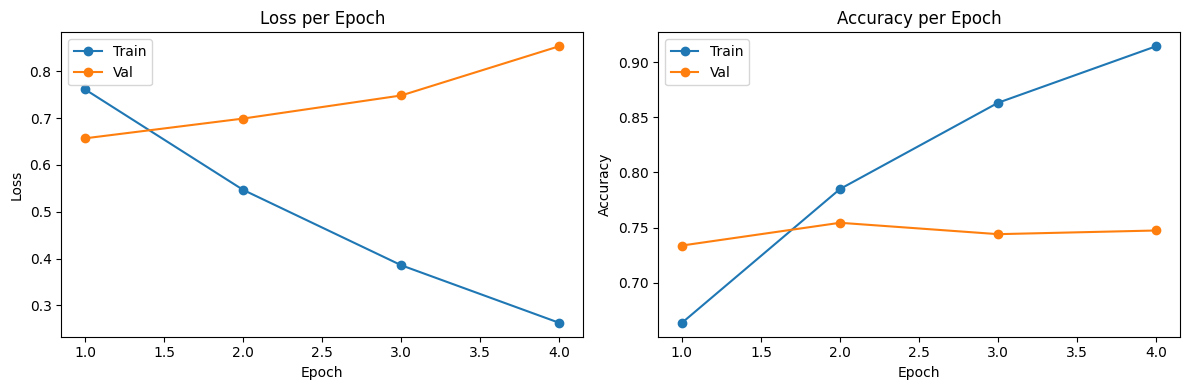

Saved: training_curve.png


In [33]:
# Cell 15 — Training curves
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_ran, history['train_loss'], marker='o', label='Train')
axes[0].plot(epochs_ran, history['val_loss'],   marker='o', label='Val')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs_ran, history['train_acc'], marker='o', label='Train')
axes[1].plot(epochs_ran, history['val_acc'],   marker='o', label='Val')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curve.png', dpi=150)
plt.show()
print('Saved: training_curve.png')

In [34]:
# Cell 16 — SVM vs DistilBERT comparison
svm_acc = 0.75   # Person 1 result
svm_f1  = {'Negative': 0.82, 'Neutral': 0.44, 'Positive': 0.82}

print('=' * 42)
print('         MODEL COMPARISON')
print('=' * 42)
print(f'SVM + TF-IDF  accuracy : {svm_acc:.4f}')
print(f'DistilBERT    accuracy : {test_acc:.4f}')
print(f'Improvement            : +{(test_acc - svm_acc)*100:.1f}%')
print('=' * 42)
print(f"{'Class':<12} {'SVM F1':>8} {'BERT F1':>9}")
print('-' * 32)
for cls in label_names:
    bert_f1 = bert_report[cls]['f1-score']
    print(f"{cls:<12} {svm_f1[cls]:>8.2f} {bert_f1:>9.2f}")

         MODEL COMPARISON
SVM + TF-IDF  accuracy : 0.7500
DistilBERT    accuracy : 0.7700
Improvement            : +2.0%
Class          SVM F1   BERT F1
--------------------------------
Negative         0.82      0.82
Neutral          0.44      0.51
Positive         0.82      0.84


In [35]:
# Cell 17 — Save outputs for Person 3
pickle.dump(bert_report, open('bert_report.pkl', 'wb'))

print('Files ready for Person 3:')
print('  best_distilbert.pt    -> push to models/ on GitHub')
print('  bert_report.pkl       -> push to models/ on GitHub')
print('  confusion_matrix.png  -> push to results/ on GitHub')
print('  training_curve.png    -> push to results/ on GitHub')

Files ready for Person 3:
  best_distilbert.pt    -> push to models/ on GitHub
  bert_report.pkl       -> push to models/ on GitHub
  confusion_matrix.png  -> push to results/ on GitHub
  training_curve.png    -> push to results/ on GitHub
